In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
class SafetyMAB:
    """
    Simulates the MAB Environment with multi-metric reward.
    """
    def __init__(self):
        self.action_names = ["Brake Hard", "Swerve Left", "Swerve Right"]
        self.num_arms = len(self.action_names)
        self.speeds = [25, 35, 45] # mph

        # Reward/Penalty mapping 
        self.REWARD_MAP = {
            'Perceived': 100,      # High reward for perception
            'NotPerceived': -500,  # Major penalty for no perception 
            'Stopped': 50,         # Mitigation success
            'NotStopped': -100,    # Mitigation failure
            'SwerveSuccess': 20,   # Alternative mitigation success
            'Impact_PerceptionFail': -1000, # Catastrophic penalty
            'Impact_TooFast': -700,         # Severe penalty
            'NoGo': -50,           # Operational penalty (but safe)
            'SafeBrake': -10,      # Minor penalty for successful braking action itself
            'SafeSwerve': -20,     # Minor penalty for successful swerve action itself 
        }

    def _get_outcome_probabilities(self, arm_index, speed):
        """
        Defines speed-dependent probability distributions for each action.
        """
        base_p_perception = 0.98 - (speed / 1000)
        
        # [P_Perception, P_Stop, P_Swerve, P_Impact_Base, P_NoGo]
        # P_Impact_Base is the probability of impact *if* the maneuver fails/is too slow.

        if arm_index == 0: # Brake Hard
            # High probability of stopping at low speed, drops quickly at high speed
            p_stop = max(0.2, 1.0 - (speed / 70.0))
            return {
                'p_perceived': base_p_perception, 
                'p_stop': p_stop,
                'p_swerve': 0.0,
                'p_impact_on_fail': min(0.9, (speed / 50.0)**2), # High speed = high impact chance on failure
                'p_nogo': 0.05 
            }
        elif arm_index == 1: # Swerve Left (High risk, high potential reward)
            # Low probability of stopping, high chance of swerve, but risky impact
            p_swerve = 0.7
            return {
                'p_perceived': base_p_perception,
                'p_stop': 0.1,
                'p_swerve': p_swerve,
                'p_impact_on_fail': 0.0, # Impact on pedestrian is low due to swerve
                'p_secondary_impact': min(0.8, (speed / 50.0)), # High chance of hitting something
                'p_nogo': 0.03
            }
        elif arm_index == 2: # Swerve Right (Medium risk)
            p_swerve = 0.6
            return {
                'p_perceived': base_p_perception,
                'p_stop': 0.15,
                'p_swerve': p_swerve,
                'p_impact_on_fail': 0.0,
                'p_secondary_impact': min(0.5, (speed / 60.0)), # Lower chance of impact than Swerve Left
                'p_nogo': 0.02
            }
        return {} # Should not happen


    def pull_arm(self, arm_index, speed):
        """Simulates the outcome of a trial given the chosen action and the current speed."""
        probs = self._get_outcome_probabilities(arm_index, speed)
        stopped = False
        total_reward = 0
        log = []

        #Perception
        perceived = random.random() < probs['p_perceived']
        if perceived:
            total_reward += self.REWARD_MAP['Perceived']
            log.append("Perception: YES (+100)")
        else:
            total_reward += self.REWARD_MAP['NotPerceived']
            log.append("Perception: NO (-500) -> Major Risk Factor")

        #Action
        impact_occurred = False
        
        if perceived:
            # Try to stop (only relevant for Brake Hard)
            stopped = random.random() < probs.get('p_stop', 0.0)
            if stopped:
                total_reward += self.REWARD_MAP['Stopped']
                log.append("Stopped: YES (+50)")
                total_reward += self.REWARD_MAP['SafeBrake'] if arm_index == 0 else 0
            else:
                total_reward += self.REWARD_MAP['NotStopped']
                log.append("Stopped: NO (-100)")
                
                # If vehicle didn't stop, check if it swerved
                swerved = random.random() < probs.get('p_swerve', 0.0)
                if swerved:
                    total_reward += self.REWARD_MAP['SwerveSuccess']
                    log.append("Swerve: YES (+20)")
                    total_reward += self.REWARD_MAP['SafeSwerve']
                else:
                    log.append("Swerve: NO (0)")
                
                #check for impact
                if not stopped and not swerved:
                    # Impact due to being too fast (or action failure)
                    if random.random() < probs['p_impact_on_fail']:
                        impact_occurred = True
                        log.append("Impact: YES (Too Fast/Action Failure)")
                        
        else:
            # If not perceived, impact likely
            if random.random() < 0.95: 
                impact_occurred = True
                log.append("Impact: YES (Perception Failure)")

        #Impact
        if impact_occurred:
            # Differentiate cause of impact for penalty
            if not perceived:
                total_reward += self.REWARD_MAP['Impact_PerceptionFail']
            else:
                total_reward += self.REWARD_MAP['Impact_TooFast']
        
        # Secondary impact check for swerve actions
        if arm_index in [1, 2] and not stopped:
            if random.random() < probs.get('p_secondary_impact', 0.0):
                total_reward += self.REWARD_MAP['Impact_TooFast'] # Use same penalty for secondary collision
                log.append("Secondary Collision: YES (-700)")


        #NoGo Check
        if random.random() < probs['p_nogo']:
            total_reward += self.REWARD_MAP['NoGo']
            log.append("NoGo: YES (-50)")

        # Log and return
        print(f"  > Metrics: {', '.join(log)}")
        print(f"  > Final Reward: {total_reward:.1f}")
        return total_reward

In [3]:
#Epsilon-Greedy Agent

class EpsilonGreedyAgent:
    def __init__(self, num_arms, epsilon=0.1):
        self.num_arms = num_arms
        self.epsilon = epsilon
        self.q_values = np.zeros((3, num_arms))  # 3 speeds x 3 actions
        self.n_counts = np.zeros((3, num_arms)) 
        self.total_rewards = []
        self.speed_map = {25: 0, 35: 1, 45: 2}

    def select_action(self, speed_idx):
        """Selects action based on Q-values specific to the current speed."""
        if np.random.rand() < self.epsilon:
            action = np.random.randint(self.num_arms)
            print(f"\nRandom action: {env.action_names[action]}")
        else:
            action = np.argmax(self.q_values[speed_idx, :])
            print(f"\nLearned action for speed: {env.action_names[action]}")
        return action

    def update(self, speed_idx, action, reward):
        """Updates the Q-value for the specific speed and action."""
        self.n_counts[speed_idx, action] += 1
        n = self.n_counts[speed_idx, action]
        q = self.q_values[speed_idx, action]
        
        self.q_values[speed_idx, action] = q + (reward - q) / n

In [4]:
#TRAINING

env = SafetyMAB()
agent = EpsilonGreedyAgent(num_arms=env.num_arms, epsilon=0.1) 
n_trials = 3000  


for trial in range(1, n_trials + 1):
    # Randomly select a speed for the trial 
    current_speed = random.choice(env.speeds)
    speed_idx = agent.speed_map[current_speed]
    
    print(f"\n--- Trial {trial} @ {current_speed} mph ---")

    action = agent.select_action(speed_idx)

    reward = env.pull_arm(action, current_speed)

    agent.update(speed_idx, action, reward)
    
    current_cumulative_reward = agent.total_rewards[-1] if agent.total_rewards else 0
    agent.total_rewards.append(current_cumulative_reward + reward)

    if trial % 500 == 0:
        print(f"\n{trial} INTERIM SUMMARY")
        print("Estimated Average Rewards by Speed:")
        for i, speed in enumerate(env.speeds):
            print(f"  {speed} mph: {agent.q_values[i, :].round(2)} (Actions: {env.action_names})")


print("\nLearned Policy")
for i, speed in enumerate(env.speeds):
    best_action_idx = np.argmax(agent.q_values[i, :])
    print(f"At {speed} mph, the best action is: {env.action_names[best_action_idx]} (Q-Value: {agent.q_values[i, best_action_idx].round(2)})")


--- Trial 1 @ 25 mph ---

Learned action for speed: Brake Hard
  > Metrics: Perception: YES (+100), Stopped: YES (+50)
  > Final Reward: 140.0

--- Trial 2 @ 25 mph ---

Learned action for speed: Brake Hard
  > Metrics: Perception: YES (+100), Stopped: YES (+50)
  > Final Reward: 140.0

--- Trial 3 @ 35 mph ---

Learned action for speed: Brake Hard
  > Metrics: Perception: YES (+100), Stopped: NO (-100), Swerve: NO (0)
  > Final Reward: 0.0

--- Trial 4 @ 45 mph ---

Learned action for speed: Brake Hard
  > Metrics: Perception: YES (+100), Stopped: YES (+50)
  > Final Reward: 140.0

--- Trial 5 @ 25 mph ---

Learned action for speed: Brake Hard
  > Metrics: Perception: YES (+100), Stopped: YES (+50)
  > Final Reward: 140.0

--- Trial 6 @ 35 mph ---

Learned action for speed: Brake Hard
  > Metrics: Perception: YES (+100), Stopped: YES (+50), NoGo: YES (-50)
  > Final Reward: 90.0

--- Trial 7 @ 45 mph ---

Learned action for speed: Brake Hard
  > Metrics: Perception: YES (+100), Stopp

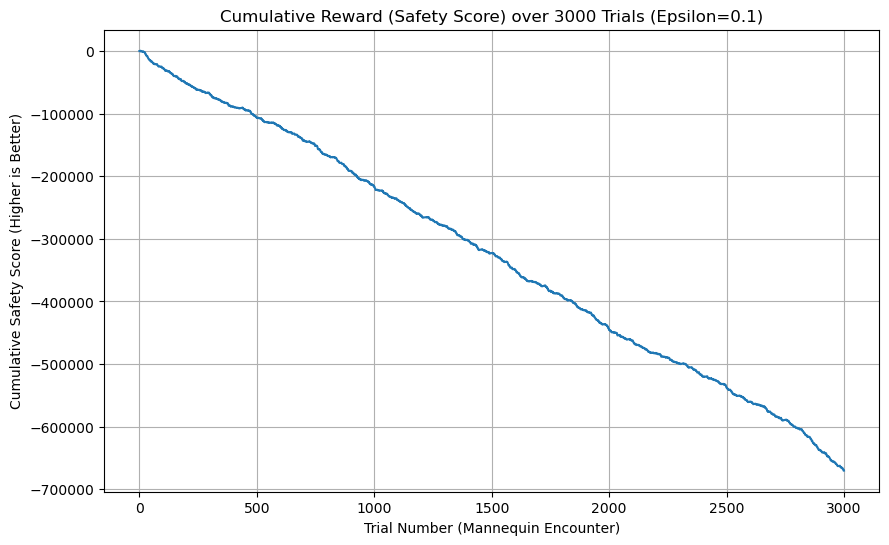

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(agent.total_rewards)
plt.title(f'Cumulative Reward (Safety Score) over {n_trials} Trials (Epsilon={agent.epsilon})')
plt.xlabel('Trial Number (Mannequin Encounter)')
plt.ylabel('Cumulative Safety Score (Higher is Better)')
plt.grid(True)
plt.show()